---
title: Week 4.2 Tutorial 1, Carbonate Buffer System
subtitle: Orchestra Scenario, Carbonate buffer system
author:
  - name: Timo Heimovaara
    affiliations: Delft University of Technology, department of Geoscience & Engineering
    orcid: 
    email: t.j.heimovaara@tudelft.nl
license: CC-BY-NC-ND-4.0 (https://creativecommons.org/licenses/by-nc-nd/4.0/).
date: 2026-01-07
kernelspec:
    name: python3
    display_name: 'Python 3.13'
---

## Studying the carbonate buffer system with pyOrchestra
This example illustrates how to use Python and ORCHESTRA to simulate the Carbonate-Buffer in water.

The next python cells imports the necessary libararies and checks the path to the input files required for the Orchestra simulation. Please note that this is only required for the jupyter-book version. For a stand-alone version of this notebook you need to start jupyter-lab from the directory with the input files.

In [1]:
# Import libraries required for running all simulations
import os
import sys
from IPython.utils import capture
from IPython.display import display, Markdown
from pathlib import Path
from contextlib import chdir

import numpy as np
import matplotlib.pyplot as plt
import PyORCHESTRA # here, the ORCHESTRA submodule is imported
import pandas as pd
import seaborn as sns

%matplotlib widget
sns.set()

# Prepare a file to capture PyOrchestra output
capture_file = open("pyorchestra_output.log", "w")


# pyOrchestra is implemented in C++
# Save original stdout file descriptor
original_stdout_fd = sys.stdout.fileno()

# Duplicate original stdout so we can restore it later
saved_stdout_fd = os.dup(original_stdout_fd)



# We need to import some Orchestra files. We need to know the path layout on 
# the local machine:
def find_book_root(start: Path | None = None) -> Path:
    """
    Walk upward from `start` (or CWD) until a directory containing Jupyter Book
    marker files is found. Returns the path to the book root.
    Raises FileNotFoundError if no root is found.
    """
    config_any = {"_config.yml", "_config.yaml"}      # some projectrs use .yaml
    myst_any = {"myst.yml", "myst.yaml"}            # jupyter-book uses _toc.yml

    cur = Path(Path.cwd()).resolve()

    for parent in [cur, *cur.parents]:
        children = {f.name for f in parent.iterdir()} if parent.exists() else set()
        has_any_config = bool(config_any & children)
        has_any_myst = bool(myst_any & children)
        if has_any_config and has_any_myst:
            return parent

    raise FileNotFoundError(
        f"Could not find Jupyter Book root (no _config.y* and myst.y* found above {cur})"
    )


def path_from_book_root(*parts: str | Path) -> Path:
    root = find_book_root()
    p = (root.joinpath(*parts)).resolve()
    if not p.exists():
        raise FileNotFoundError(f"Path not found: {p}")
    return p

# In order for orchestra to run we need to change directory to the directory with the input file:


# Example usage:
# input_file = path_from_book_root("content", "week 02", "Orchestra_simulation", "chemistry1.inp")
# print("Input file:", input_file)
   
orchestra_path = path_from_book_root("content", "week 4.2", "Week 4.2_Tutorial-1-ChemicalBuffersSystems")
# print(orchestra_path)

## Define chemical system: Carbonate & Water buffer system using the ORCHESTRA-GUI

We define the master species, and some cations which will be used to implicitly add H+ by allowing the system to manage the charge balance with pH!

In order to solve a chemical equilibrium problem with pyOrchestra, we need to define our chemical system first. Orchestra defines this system with a number of text files. The most important one is the so-called chemistry input file (*chemistry_carbonate_buffer.inp*). This file is most easily made using the Orchestra GUI which can be accessed by clicking on the orchestra2026.jar file.

Similar to the first tutorial of this week we start with a skeleton problem (a working ORCHESTRA simulation and it is convenient to start with the results from tutorial 1) and then adjust the files step by step. 

Using the steps described in Tutorial 1 we created *chemistry_carbonate_buffer.inp*. The carbonate system we want to analyse is controlled by the following reactions (see also Appelo & Postma, chapter 5).

![Appelo&Postma_Table5_3.png](images/Appelo&Postma_Table5_3.png)

The log K values we use for our simulation come from the PHREEQC database and are slightly different. 

| reaction | log K |
| ---| --- |
| $\text{CO}_2\text{(g)} + \text{H}_2\text{O} \leftrightharpoons \text{H}_2\text{CO}_3^*$ | -1.468 |
| $\text{H}_2\text{CO}_3^* \leftrightharpoons \text{H}^+ + \text{HCO}_3^- $| -6.352 |
|$\text{HCO}_3^- \leftrightharpoons \text{H}^+ + \text{CO}_3^{-2} $| -10.329 |

In addtion we add Na+ and Cl- as counter ions. 

```{exercise} Carbonate buffer
A chemical buffer is a solution in which more or less equal amounts of a weak acid and its conjugate base are present. Buffers are essential systems for the living nature as buffers resist pH change. The carbonate buffer systems are very important for controlling the pH in the oceans and in our blood.

For a chemical buffer system we can derive the following relationship from the mass-action law:
$$
pH = - \log K + \log(\frac{\text{A}^-}{\text{HA}})
$$
where $\text{HA}$ is the weak acid and $\text{A}^-$ is its conjugate base.

If we would add 0.1 mol/l of acid to pure water the pH would drop to 1, however adding it to a buffer system would cause the concentration of the base to decrease with roughly 0.1 mol/l and the weak acid to increase with 0.1 mol/l. Assuming a buffer with 0.5 mol/l weak acid and base, you can see that the ratio in the log changes by 0.4/0.6 = 2/3 of which the log10 is about -0.18. This clearly shows that the buffer solution counteracts the change in pH.

```
As we will be working with a system that contains at least two phases (gas & water) sometimes also a third (solids), we require a back ground gas to maintain gas pressure in the case all of the gaseous species in our reaction were to be consumed. For our case we choose to use Ar[g] at a background pressure of 1 atm. Argon is an inert gas and will not influence our reactions.


```{exercise} Why is it important to have a background gas?
```
Finally we require Orchestra to control the charge balance, we assume that $\text{Na}^+$ and $\text{Cl}^-$ are present in the sytem as well because we assume that we will be able to change the pH in the solution using $\text{HCl}$ or $\text{NaOH}$.

Using all insights from above we generated the following master species table: 

|Primary entity|Phase|Input Variable|Fix log activity|Log activity|Concentration|Phase|Expression|
|--|--|--|--|--|--|--|--|
|Ar[g]|gas||x|0||||
|CO3-2|diss||||1.0e-9|tot||
|Cl-|diss||||1.0e-9|tot||
|H+|diss|pH|x|7.0|||H.logact=-pH|
|H2O|liter||x|-0.0||||
|Na+|diss||||1.0e-9|tot||

Orchestra will use these primary entities, and their initial values to calculate the total elemental composition in the complete system. The fixed log-activties indicate that the total can vary during the simulation, as long as the log-activity condition is maintained or because Orchestra uses these values to balance the charge of the solution (Na+.tot and Cl-.tot). 

### Phases & Reactions
On the **Phases & Reactions** tab shown in figure [](#phases_reactions) we define the reaction network of our system. Please ensure that all relevant reactions are marked.

### Other tabs
There is no need to change anything on the other tabs as these are correctly set.

### Using Orchestra to run the scenario
It is possible to use the ORCHESTRA GUI to run the simulation, and this has been prepared using the **Input** and **Output** tabs on the right of the window. Please have look at these tabs and they should be rather "self explanatory". 



## Running the Carbonate-Water Buffer system scenario in a Python notebook
We will run some test scenarios to illustrate the importance of carbonate and $\text{CO}_3^{-2}\text{(aq)}$ in controlling the pH of water.

We follow the same systematic approach as Tutorial 1, which consists of the following standard steps:
1. define the domain for our problem
2. define the primary species which change during our scenario
3. initialize the problem
4. run the problem
5. process the output

### 1. Define the domain
For our analysis we choose to work with a system containing 1 liter of water and 1 liter of gas phase. The volume of the solid phase is small with respect the total volume and will be neglected for now.

### 2. Define the primary species
The primary species are as defined above with the ORCHESTRA GUI. Please note that the values required by ORCHESTRA have to be in moles. In order to get moles/liter the volume of water has to be set to 1 liter, and the density of water need to be given as well.

### 3. Initialise the problem 
**Defining the buffer concentrations**
The initial condition for our problem will be defined by setting the amounts of $\text{CO}_3^{-2}\text{(aq)}$ and $\text{Na}^+$ in our system with CO3-2.tot and Na+.tot. In order to determine the concentrations to add, you start by defining the concentration $\text{CO}_3^{-2}\text{(aq)}$. For a non-buffered $\text{Na}_2\text{CO}_3$ system the amount of sodium is twice the amount of carbonate. For a buffer made with equal amounts of $\text{Na}_2\text{CO}_3$ and $\text{NaHCO}_3$ tje sodium concentration is 1.5 times the amount of carbonate. For the bicarbonate buffer the amount of sodium is half the amount of carbonate. This works because we allow ORCHESTRA to balance the charge using the pH. 

Because ORCHESTRA manages the charge using the pH, we can add acid by adding $\text{Cl}^-$ and base by adding $\text{Na}^+$

**Initialization code**
ORCHESTRA is initialized in pyOrchestra using the inputfile *chemistry_carbonate_buffer.inp*, created above with the ORCHESTRA-GUI. After initialization in Python, we know which variables will be passed through *OutVars* and can be used in *InVars*.

The following code shows how to do this.
```{note} 
It is relatively easy to change the OutVars array. In order to find all possible variables in ORCHESTRA, check the **Phases & Reactions** tab on the **Chemistry** tab in the ORCHESTRA-GUI. The GUI also has a tab *Output selector* where you can easily generate lists of output variables belonging to certain species.
```


In [2]:
#--- Model setup --- 
# for initialization we need to temporarily move to the directory containing the 'chemistry1.inp' file.
with chdir(orchestra_path):

    # Input file is generated with Orchestra GUI
    InputFile = 'chemistry_carbonate_buffer.inp'
    NoCells = 1 #only 1 cell to have a 0-D system with 1liter of water
    
    # We define the input variables that will be changed in the script
    InVars = np.array(['pH',
                       'Na+.tot', 
                       'CO3-2.tot',
                       'Cl-.tot',
                       'watervolume',
                       'gasvolume',
                       'gastype',
                       ])
    
    # We select the output from Orchestra we need to use
    OutVars = np.array(['pH', 'H+.con', 'H+.tot', 'H+.logact',
                        'OH-.tot', 'OH-.con', 'OH-.logact',
                        'CO2[g].tot', 'CO2[g].con', 'CO2[g].diss', 'CO2[g].logact',
                        'CO3-2.tot', 'CO3-2.con', 'CO3-2.logact','CO3-2.diss',
                        'HCO3-.tot', 'HCO3-.con', 'HCO3-.logact', 'HCO3-.diss',
                        'H2CO3.tot', 'H2CO3.con', 'H2CO3.logact', 'H2CO3.diss',
                        'Cl-.tot', 'Cl-.con', 'Cl-.logact', 'Cl-.diss', 
                        'Na+.tot', 'Na+.con', 'Na+.logact', 'Na+.diss',
                        'NaCO3-.con', 'NaHCO3.con',  
                        'I', 'chargebalance', 'watervolume', 'gasvolume','pressure' ])

    # Associate a variable with the pyOrchestra.ORCHESTRA() class
    p = PyORCHESTRA.ORCHESTRA()

    # Initialize the class with the parameters defined above
    p.initialise(InputFile, NoCells, InVars, OutVars)


Reading and expanding calculator new stylechemistry_carbonate_buffer.inp
Scanning file: chemistry_carbonate_buffer.inp
Scanning file: objects2026_THe.txt
Scanning file: chemistry_carbonate_buffer.inp
Scanning file: objects2026_THe.txt
Including file: chemistry_carbonate_buffer.inp
Scanning file: objects2026_THe.txt
0.011 sec.
	Reading variables .... 0.004 s
testing:
13:pH
15:Na+.tot
10:CO3-2.tot
12:Cl-.tot
16:watervolume
17:gasvolume
18:gastype
13:pH
19:H+.con
20:H+.tot
21:H+.logact
22:OH-.tot
23:OH-.con
24:OH-.logact
25:CO2[g].tot
26:CO2[g].con
27:CO2[g].diss
28:CO2[g].logact
10:CO3-2.tot
29:CO3-2.con
9:CO3-2.logact
30:CO3-2.diss
31:HCO3-.tot
32:HCO3-.con
33:HCO3-.logact
34:HCO3-.diss
35:H2CO3.tot
36:H2CO3.con
37:H2CO3.logact
38:H2CO3.diss
12:Cl-.tot
39:Cl-.con
11:Cl-.logact
40:Cl-.diss
15:Na+.tot
41:Na+.con
14:Na+.logact
42:Na+.diss
43:NaCO3-.con
44:NaHCO3.con
3:I
7:chargebalance
16:watervolume
17:gasvolume
45:pressure
Initialise Completed! the following IO parameters will be used:
0

Please note that the output of this code is what ORCHESTRA echos back. ORCHESTRA uses a set of variables in order to store the input variables and the results of the calculations. The top part of the output shows the output requested by us through *OutVars* together with the values used during initialization.

### Run the Problem
The aim of the scenario for now is to setup the non-buffered carbonate system. The phrase non-buffered is a little misleading here, as carbonate has buffering properties of itself. The non-buffered system here is a system where we only add carbonate to the system as base. So not as a weak acid, base pair.

A non buffered system has only the acid or only the base component of the buffer. In this example we create a non-buffered carbonate adding only $\text{Na}_2\text{CO}_3$. We start with a carbonate concentration of 0.5 mol / liter

In [3]:
# %%
# Step 1, initial condition.
# InVars need to contain floats
IN = np.array([np.ones_like(InVars)]).astype(float)

# Define initial conditions
CO32_ini = 0.1 # mol
Na_ini = 0.2 # mol. We define the liquid volume to 1 liter, so we add 1 mol/l Na2CO3

IN[0][np.where(InVars == 'CO3-2.tot')] = CO32_ini # moles
IN[0][np.where(InVars == 'Na+.tot')] = Na_ini # moles
IN[0][np.where(InVars == 'Cl-.tot')] = 1e-20 # No Chloride (initial conditions)
IN[0][np.where(InVars == 'watervolume')] = 1.0 # 1 liter
IN[0][np.where(InVars == 'gasvolume')] = 1.0 # 1 liter

# Calculate equilibrium conditions for initial situation 
OUT = p.set_and_calculate(IN)
Res_initial = pd.DataFrame(OUT,columns=OutVars)
print(Res_initial.T)

                          0
pH             1.142210e+01
H+.con         5.156499e-12
H+.tot         3.137337e-03
H+.logact     -1.142210e+01
OH-.tot        3.137337e-03
OH-.con        3.137337e-03
OH-.logact    -2.674297e+00
CO2[g].tot     5.899556e-08
CO2[g].con     5.663944e-07
CO2[g].diss    0.000000e+00
CO2[g].logact -6.246881e+00
CO3-2.tot      1.000000e-01
CO3-2.con      9.686276e-02
CO3-2.logact  -1.551675e+00
CO3-2.diss     9.999994e-02
HCO3-.tot      3.137142e-03
HCO3-.con      3.137142e-03
HCO3-.logact  -2.644778e+00
HCO3-.diss     3.137142e-03
H2CO3.tot      1.928053e-08
H2CO3.con      1.928053e-08
H2CO3.logact  -7.714881e+00
H2CO3.diss     1.928053e-08
Cl-.tot        1.000000e-20
Cl-.con        4.914778e-18
Cl-.logact    -1.744295e+01
Cl-.diss       4.914778e-18
Na+.tot        2.000000e-01
Na+.con        2.000000e-01
Na+.logact    -8.334280e-01
Na+.diss       2.000000e-01
NaCO3-.con     0.000000e+00
NaHCO3.con     0.000000e+00
I              2.968628e-01
chargebalance  0.000

### Step 2: Simulate the addition of a strong acid (HCl)
We add acid by adding Cl- in small increments. H+ is added implicitly as we allow Orchestra to balance charge using the pH.

```{note}
We start by adding 1e-5 mol/l $\text{HCl}$. In an unbuffered system the pH would drop to 5 after the first addition. 
Our simulation is rather extreme as at the end of the experiment we have added 10 mol/l $\text{HCl}$. Please note that we assume the acid is added in an infinitely high concentration (i.e. no additional water is added)
```

In [4]:
# Define the incremental pH change

Cl_range = np.logspace(-5, 1, 201)

#  Prepare an array to store all results from our scenario
all_Res = np.zeros([len(Cl_range),len(OutVars)])

# loop over pH_Range 
# we use a counter ii in order to store the results
ii = -1
for Cl in Cl_range:
    
    IN[0][np.where(InVars == 'Cl-.tot')] = Cl

    # run ORCHESTRA
    OUT = p.set_and_calculate(IN)
    ii = ii + 1
    all_Res[ii] = OUT[0]

    # Create a dataframe from all_Res
Res_non_buffered = pd.DataFrame(all_Res,columns=OutVars)

Try a first calculation with iia switched off....
Parsing expressions of chemistry_carbonate_buffer.inp..... 
Optimizing expressions of chemistry_carbonate_buffer.inp..... 0.024 sec.
1290 variables, 3169 expressions, 4 equations.
First calculation was successful!
Repeat calculation with iia switched on..
Switching on: logI: -2
Switching on: pH: 1
This was successful!!
chemistry_carbonate_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_carbonate_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_carbonate_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_carbonate_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_carbonate_buffer.inp: Improving start estim

## Process Output
To process the output we plot the pH as a function of the added chloride.

In [5]:
Res_non_buffered[['pH','Cl-.tot']]


,pH,Cl-.tot
0,11.421400,0.000010
1,11.421350,0.000011
2,11.421296,0.000011
3,11.421239,0.000012
4,11.421177,0.000013
...,...,...
196,-1.654907,7.585776
197,-1.765288,8.128305
198,-1.881608,8.709636
199,-2.004297,9.332543


Text(0, 0.5, 'pH')

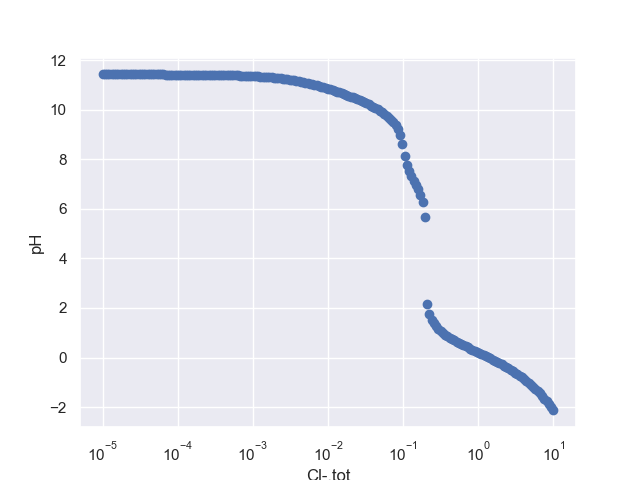

In [6]:
# Process output
# we can easily make the plot 
fig1,ax1 = plt.subplots()
# sns.scatterplot(data = Res_Simulation[['Cl-.tot','pH']],x = 'Cl-.tot', y='pH', ax=ax1)
ax1.plot(Res_non_buffered['Cl-.tot'],Res_non_buffered['pH'],'o')
ax1.grid(True)
ax1.set_xscale('log')
ax1.set_xlabel('Cl-.tot')
ax1.set_ylabel(r'pH')


``` {note}
The high initial pH of this $\text{Na}_2\text{CO}_3$ system may come as a surprise. We have only added the salt to pure water. $\text{Na}^+$ will immediately dissolve, and the carbonate will start to react with the water based on th carbonate equilibria, so some HCO3 will form as the original pH is around 7. We have set ORCHESTRA to compensate any charge balance errors with the pH. If you switch this off, you will see that the calculation results in a large chargebalance error which is positive. Apparently the original pH is too low. 

```

### Assignment 1. Modify the scripts above to create a buffered carbonate system
The carbonate buffer system is based on the simultneous presence of bicarbonate ($\text{HCO}_3^-$) and carbonate ($\text{CO}_3^{-2}$). This buffer system is the main system for buffering the pH in oceans, allowing ocean life to thrive in a consistent environment.

In order to create a buffered carbonate system you add the weak acid and its base in similar amounts to the solution. This is easily done using the above codes as a template.

Please make a similar plot as above where you plot pH against Cl-.tot for a buffered system. Plot both the results for the buffered and the non-buffered system.

In [7]:
# %%
# Buffered carbonate system
# Step 1, initial condition.
# InVars need to contain floats
IN = np.array([np.ones_like(InVars)]).astype(float)

# Define initial conditions
# 50% NaHCO3 and 50% Na2CO3
CO32_ini = 0.1 # 
Na_ini = 0.15 # moles note: Na is 1.5 times CO3-2 instead 2 times!

IN[0][np.where(InVars == 'CO3-2.tot')] = CO32_ini # moles
IN[0][np.where(InVars == 'Na+.tot')] = Na_ini # No Gypsum (initial conditions)
IN[0][np.where(InVars == 'Cl-.tot')] = 1e-20 # No Chloride (initial conditions)
IN[0][np.where(InVars == 'watervolume')] = 1.0 # 1 liter
IN[0][np.where(InVars == 'gasvolume')] = 1.0 # 1 liter

# Calculate equilibrium conditions for initial situation 
OUT = p.set_and_calculate(IN)
Res_initial = pd.DataFrame(OUT,columns=OutVars)
print(Res_initial.T)

# Define the incremental pH change

Cl_range = np.logspace(-5, 1, 201)

#  Prepare an array to store all results from our scenario
all_Res = np.zeros([len(Cl_range),len(OutVars)])

# loop over pH_Range 
# we use a counter ii in order to store the results
ii = -1
for Cl in Cl_range:
    
    IN[0][np.where(InVars == 'Cl-.tot')] = Cl

    # run ORCHESTRA
    OUT = p.set_and_calculate(IN)
    ii = ii + 1
    all_Res[ii] = OUT[0]

    # Create a dataframe from all_Res
Res_buffered = pd.DataFrame(all_Res,columns=OutVars)

                          0
pH             9.947689e+00
H+.con         1.511157e-10
H+.tot         5.010044e-02
H+.logact     -9.947689e+00
OH-.tot        1.004416e-04
OH-.con        1.004416e-04
OH-.logact    -4.148711e+00
CO2[g].tot     2.896305e-05
CO2[g].con     2.780605e-04
CO2[g].diss    0.000000e+00
CO2[g].logact -3.555861e+00
CO3-2.tot      1.000000e-01
CO3-2.con      4.994746e-02
CO3-2.logact  -1.809482e+00
CO3-2.diss     9.997104e-02
HCO3-.tot      5.000465e-02
HCO3-.con      5.000465e-02
HCO3-.logact  -1.428171e+00
HCO3-.diss     5.000465e-02
H2CO3.tot      9.465407e-06
H2CO3.con      9.465407e-06
H2CO3.logact  -5.023861e+00
H2CO3.diss     9.465407e-06
Cl-.tot        1.000000e-20
Cl-.con        6.877360e-14
Cl-.logact    -1.328958e+01
Cl-.diss       6.877360e-14
Na+.tot        1.500000e-01
Na+.con        1.500000e-01
Na+.logact    -9.509076e-01
Na+.diss       1.500000e-01
NaCO3-.con     0.000000e+00
NaHCO3.con     0.000000e+00
I              1.999475e-01
chargebalance  0.000

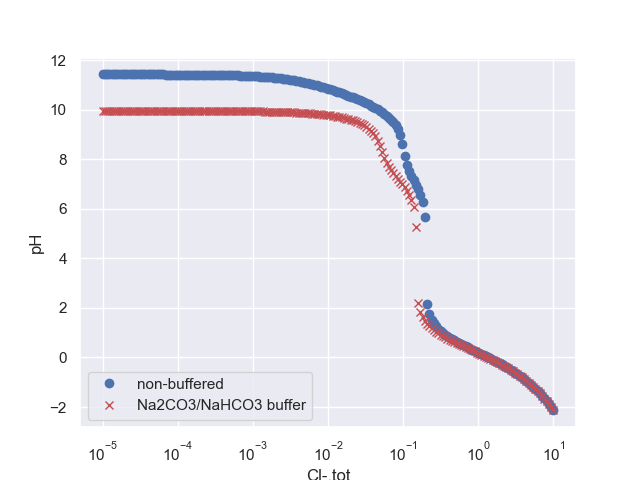

In [8]:
# Process output
# we can easily make the plot 
fig4,ax4 = plt.subplots()
# sns.scatterplot(data = Res_Simulation[['Cl-.tot','pH']],x = 'Cl-.tot', y='pH', ax=ax1)
ax4.plot(Res_non_buffered['Cl-.tot'],Res_non_buffered['pH'],'o')
ax4.plot(Res_buffered['Cl-.tot'],Res_buffered['pH'],'rx')
ax4.grid(True)
ax4.set_xscale('log')
ax4.set_xlabel('Cl-.tot')
ax4.set_ylabel(r'pH')
ax4.legend(['non-buffered', 'Na2CO3/NaHCO3 buffer'])


### Explain your results
Adding carbonate as a buffer, i.e. with a weak acid and it's base lowers the initial pH to a value close to the log K of the buffer system (pH = 10.3) because the initial amounts of weak acid and base are identical. Adding up to 0.01 mol of acid, has only a limited impact on the pH of the system, further increasing the amounts of acid, will have an impact as the amount of base to buffer the pH is all consumed. The pH pattern will follow the reacations of carbonate in acid environments.

### Assignment 2. Modify the scripts above to create a buffered carbonic acid system
The carbonic acid buffer system is based on the simultaneous presence of carbonic acid ($\text{H}_2\text{CO}_3$) and bicarbonate ($\text{HCO}_3^-$). This is main system our body uses to buffer the pH in our blood.

Please make a similar plot as above where you plot pH against Cl-.tot for a buffered system. Plot both the results for the buffered and the non-buffered system.

In [11]:
# %%
# Buffered carbonate system
# Step 1, initial condition.
# InVars need to contain floats
IN = np.array([np.ones_like(InVars)]).astype(float)

# Define initial conditions
# 50% NaHCO3 and 50% Na2CO3
CO32_ini = 0.10 # 
Na_ini = 0.05 # moles note 0.5 times the amount CO3-2

IN[0][np.where(InVars == 'CO3-2.tot')] = CO32_ini # moles
IN[0][np.where(InVars == 'Na+.tot')] = Na_ini # No Gypsum (initial conditions)
IN[0][np.where(InVars == 'Cl-.tot')] = 1e-20 # No Chloride (initial conditions)
IN[0][np.where(InVars == 'watervolume')] = 1.0 # 1 liter
IN[0][np.where(InVars == 'gasvolume')] = 1.0 # 1 liter

# Calculate equilibrium conditions for initial situation 
OUT = p.set_and_calculate(IN)
Res_initial = pd.DataFrame(OUT,columns=OutVars)
print(Res_initial.T)

#  Prepare an array to store all results from our scenario
all_Res = np.zeros([len(Cl_range),len(OutVars)])

# loop over pH_Range 
# we use a counter ii in order to store the results
ii = -1
for Cl in Cl_range:
    
    IN[0][np.where(InVars == 'Cl-.tot')] = Cl

    # run ORCHESTRA
    OUT = p.set_and_calculate(IN)
    ii = ii + 1
    all_Res[ii] = OUT[0]

    # Create a dataframe from all_Res
Res_buffered2 = pd.DataFrame(all_Res,columns=OutVars)




                          0
pH             6.976331e+00
H+.con         1.286020e-07
H+.tot         1.500001e-01
H+.logact     -6.976331e+00
OH-.tot        9.347207e-08
OH-.con        9.347207e-08
OH-.logact    -7.120070e+00
CO2[g].tot     3.039376e-02
CO2[g].con     2.885740e-01
CO2[g].diss    0.000000e+00
CO2[g].logact -5.397428e-01
CO3-2.tot      1.000000e-01
CO3-2.con      4.038614e-05
CO3-2.logact  -4.736082e+00
CO3-2.diss     6.960624e-02
HCO3-.tot      4.991926e-02
HCO3-.con      4.991926e-02
HCO3-.logact  -1.383412e+00
HCO3-.diss     4.991926e-02
H2CO3.tot      9.823296e-03
H2CO3.con      9.823296e-03
H2CO3.logact  -2.007743e+00
H2CO3.diss     9.823296e-03
Cl-.tot        1.000000e-20
Cl-.con        7.154817e-14
Cl-.logact    -1.323098e+01
Cl-.diss       7.154817e-14
Na+.tot        5.000000e-02
Na+.con        5.000000e-02
Na+.logact    -1.386608e+00
Na+.diss       5.000000e-02
NaCO3-.con     0.000000e+00
NaHCO3.con     0.000000e+00
I              5.004052e-02
chargebalance  0.000

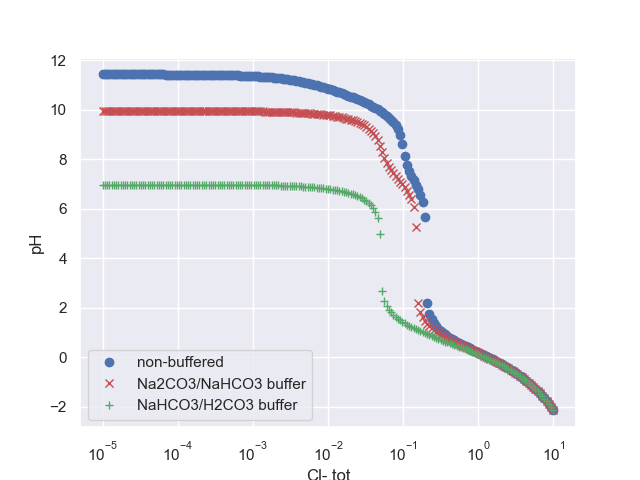

In [12]:
# Process output
# we can easily make the plot 
fig5,ax5 = plt.subplots()
# sns.scatterplot(data = Res_Simulation[['Cl-.tot','pH']],x = 'Cl-.tot', y='pH', ax=ax1)
ax5.plot(Res_non_buffered['Cl-.tot'],Res_non_buffered['pH'],'o')
ax5.plot(Res_buffered['Cl-.tot'],Res_buffered['pH'],'rx')
ax5.plot(Res_buffered2['Cl-.tot'],Res_buffered2['pH'],'g+')
ax5.grid(True)
ax5.set_xscale('log')
ax5.set_xlabel('Cl-.tot')
ax5.set_ylabel(r'pH')

ax5.legend(['non-buffered', 'Na2CO3/NaHCO3 buffer', 'NaHCO3/H2CO3 buffer' ])

The pH of this buffer system is very close to 7, close to the log K of the reaction (6.3). Similar as a above the buffer works well until about 0.01 mol/l of acid.